In [1]:
import json
import pandas as pd
import numpy as np

from tqdm import tqdm

import matplotlib.pyplot as plt

In [4]:
candidates = []

with open("/content/drive/MyDrive/Redrob-Hackathon/data/candidates.jsonl", "r", encoding="utf-8") as f:

    for line in tqdm(f):

        if line.strip():

            candidates.append(json.loads(line))

print(len(candidates))

100000it [00:14, 6687.39it/s]

100000


In [5]:
candidate = candidates[0]

for key in candidate.keys():
    print(key)

candidate_id
profile
career_history
education
skills
certifications
languages
redrob_signals


In [6]:
candidate["profile"]

{'anonymized_name': 'Ira Vora',
 'headline': 'Backend Engineer | SQL, Spark, Cloud',
 'summary': "Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid — Spark, Airflow, SQL warehouses are home territory; I'm building competence on the ML side. My toolkit is solid on the data engineering side — Python, SQL, Spark, Airflow, warehouse design — and I've completed a couple of self-directed ML projects (Kaggle competitions, side projects fine-tuning small models). Interested in transitioning toward more AI/ML-focused work, ideally at a company where I can leverage my existing data-infra skills while learning modern ML practice.",
 'location': 'Toronto',
 'country': 'Canada',
 'years_of_experience': 6.9,
 'current_title': 'Backend Engineer',
 'current_company': 'Mindtree',
 'current_company_size': '10001+',
 'current_industry': 'IT Services'}

In [7]:
candidate["career_history"]

[{'company': 'Mindtree',
  'title': 'Backend Engineer',
  'start_date': '2024-03-08',
  'end_date': None,
  'duration_months': 27,
  'is_current': True,
  'industry': 'IT Services',
  'company_size': '10001+',
  'description': 'Implemented streaming data pipelines on Kafka and Spark Streaming for a real-time user-activity processing platform. Designed the schema-registry integration, the watermark/state management approach, and the deduplication logic for late-arriving events. Worked closely with the data science team to make sure feature pipelines aligned with what their models needed. Most of my career has been data engineering, with some adjacent ML exposure.'},
 {'company': 'Dunder Mifflin',
  'title': 'Analytics Engineer',
  'start_date': '2019-07-03',
  'end_date': '2024-01-08',
  'duration_months': 55,
  'is_current': False,
  'industry': 'Paper Products',
  'company_size': '201-500',
  'description': 'Built and maintained data pipelines on Apache Airflow processing ~500GB of da

In [8]:
candidate["skills"][:5]

[{'name': 'Tailwind',
  'proficiency': 'intermediate',
  'endorsements': 3,
  'duration_months': 13},
 {'name': 'NLP',
  'proficiency': 'advanced',
  'endorsements': 37,
  'duration_months': 26},
 {'name': 'Image Classification',
  'proficiency': 'advanced',
  'endorsements': 7,
  'duration_months': 40},
 {'name': 'Fine-tuning LLMs',
  'proficiency': 'advanced',
  'endorsements': 21,
  'duration_months': 36},
 {'name': 'Weights & Biases',
  'proficiency': 'intermediate',
  'endorsements': 13,
  'duration_months': 30}]

In [9]:
candidate["redrob_signals"]

{'profile_completeness_score': 86.9,
 'signup_date': '2025-10-16',
 'last_active_date': '2026-05-20',
 'open_to_work_flag': True,
 'profile_views_received_30d': 23,
 'applications_submitted_30d': 2,
 'recruiter_response_rate': 0.34,
 'avg_response_time_hours': 177.8,
 'skill_assessment_scores': {'NLP': 38.8,
  'Image Classification': 64.8,
  'Fine-tuning LLMs': 41.6,
  'Speech Recognition': 53.7},
 'connection_count': 356,
 'endorsements_received': 35,
 'notice_period_days': 60,
 'expected_salary_range_inr_lpa': {'min': 18.7, 'max': 36.1},
 'preferred_work_mode': 'onsite',
 'willing_to_relocate': False,
 'github_activity_score': 9.2,
 'search_appearance_30d': 249,
 'saved_by_recruiters_30d': 4,
 'interview_completion_rate': 0.71,
 'offer_acceptance_rate': 0.58,
 'verified_email': True,
 'verified_phone': True,
 'linkedin_connected': False}

In [10]:
experience = []

for c in candidates:

    experience.append(
        c["profile"]["years_of_experience"]
    )

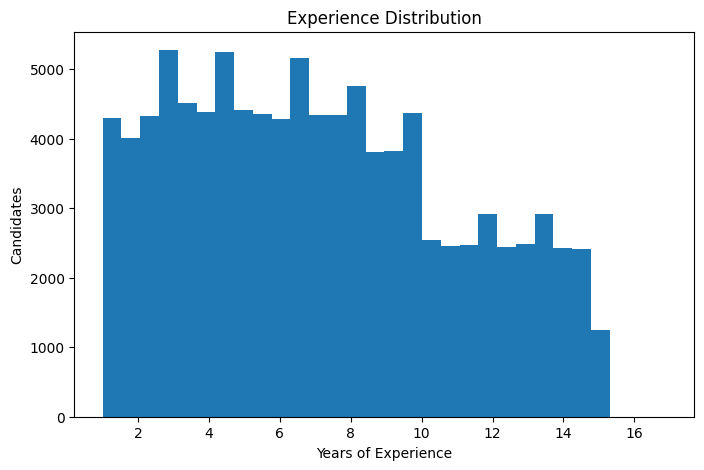

In [11]:
plt.figure(figsize=(8,5))

plt.hist(experience, bins=30)

plt.xlabel("Years of Experience")

plt.ylabel("Candidates")

plt.title("Experience Distribution")

plt.show()

In [12]:
titles = []

for c in candidates:

    titles.append(
        c["profile"]["current_title"]
    )

title_df = pd.Series(titles)

title_df.value_counts().head(20)

,count
Business Analyst,5833
HR Manager,5830
Mechanical Engineer,5791
Accountant,5764
Project Manager,5754
Customer Support,5750
Operations Manager,5744
Content Writer,5727
Sales Executive,5713
Civil Engineer,5702


In [13]:
companies = []

for c in candidates:

    companies.append(
        c["profile"]["current_company"]
    )

pd.Series(companies).value_counts().head(20)

,count
Infosys,7590
Wayne Enterprises,7571
Wipro,7566
Initech,7528
Pied Piper,7500
Globex Inc,7492
Acme Corp,7490
Dunder Mifflin,7467
TCS,7451
Hooli,7378


In [14]:
industries = []

for c in candidates:

    industries.append(
        c["profile"]["current_industry"]
    )

pd.Series(industries).value_counts()

,count
IT Services,29881
Software,22417
Manufacturing,22305
Conglomerate,7571
Paper Products,7467
Fintech,2808
Food Delivery,2514
E-commerce,1529
Consulting,1274
EdTech,610


In [15]:
countries = []

for c in candidates:

    countries.append(
        c["profile"]["country"]
    )

pd.Series(countries).value_counts()

,count
India,75113
USA,9978
Australia,2579
Canada,2506
UK,2472
Germany,2469
Singapore,2453
UAE,2430


In [16]:
tiers = []

for c in candidates:

    if len(c["education"]) > 0:

        tiers.append(
            c["education"][0]["tier"]
        )

pd.Series(tiers).value_counts()

,count
tier_3,38047
tier_4,37235
tier_2,19853
tier_1,4865


In [17]:
skill_count = []

for c in candidates:

    skill_count.append(
        len(c["skills"])
    )

pd.Series(skill_count).describe()

,0
count,100000.00000
mean,9.60302
std,3.31163
min,5.00000
25%,7.00000
50%,9.00000
75%,11.00000
max,23.00000


In [18]:
profile_scores = []

for c in candidates:

    profile_scores.append(
        c["redrob_signals"]["profile_completeness_score"]
    )

pd.Series(profile_scores).describe()

,0
count,100000.000000
mean,56.758180
std,17.274069
min,25.000000
25%,42.200000
50%,56.800000
75%,71.600000
max,99.900000


In [19]:
github_scores = []

for c in candidates:

    github_scores.append(
        c["redrob_signals"]["github_activity_score"]
    )

pd.Series(github_scores).describe()

,0
count,100000.000000
mean,9.619230
std,17.761394
min,-1.000000
25%,-1.000000
50%,-1.000000
75%,16.700000
max,96.900000


In [20]:
open_to_work = []

for c in candidates:

    open_to_work.append(
        c["redrob_signals"]["open_to_work_flag"]
    )

pd.Series(open_to_work).value_counts()

,count
False,64661
True,35339


In [21]:
notice = []

for c in candidates:

    notice.append(
        c["redrob_signals"]["notice_period_days"]
    )

pd.Series(notice).describe()

,0
count,100000.000000
mean,87.385800
std,36.589628
min,0.000000
25%,60.000000
50%,90.000000
75%,120.000000
max,150.000000


In [22]:
rows = []

for c in tqdm(candidates):

    p = c["profile"]

    r = c["redrob_signals"]

    row = {

        "candidate_id": c["candidate_id"],

        "title": p["current_title"],

        "experience": p["years_of_experience"],

        "company": p["current_company"],

        "industry": p["current_industry"],

        "country": p["country"],

        "location": p["location"],

        "num_skills": len(c["skills"]),

        "profile_score": r["profile_completeness_score"],

        "github_score": r["github_activity_score"],

        "notice_period": r["notice_period_days"],

        "open_to_work": r["open_to_work_flag"],

        "response_rate": r["recruiter_response_rate"],

        "saved_by_recruiters": r["saved_by_recruiters_30d"],

        "last_active": r["last_active_date"]

    }

    rows.append(row)

feature_df = pd.DataFrame(rows)

feature_df.head()

100%|██████████| 100000/100000 [00:00<00:00, 112994.50it/s]


,candidate_id,title,experience,company,industry,country,location,num_skills,profile_score,github_score,notice_period,open_to_work,response_rate,saved_by_recruiters,last_active
0,CAND_0000001,Backend Engineer,6.9,Mindtree,IT Services,Canada,Toronto,17,86.9,9.2,60,True,0.34,4,2026-05-20
1,CAND_0000002,Operations Manager,12.5,Wipro,IT Services,India,"Chennai, Tamil Nadu",9,78.7,-1.0,60,True,0.29,10,2025-11-12
2,CAND_0000003,Customer Support,1.1,TCS,IT Services,USA,Austin,6,31.9,-1.0,150,False,0.46,4,2026-03-21
3,CAND_0000004,Marketing Manager,3.8,Dunder Mifflin,Paper Products,Australia,Sydney,10,28.5,-1.0,120,False,0.26,8,2026-03-25
4,CAND_0000005,Accountant,11.0,Stark Industries,Manufacturing,India,"Gurgaon, Haryana",6,84.6,-1.0,30,True,0.37,1,2025-10-01


In [24]:
feature_df.to_csv(
    "/content/drive/MyDrive/Redrob-Hackathon/output/basic_features.csv",
    index=False)